# LSTM — Full Forward and Backward Derivation (with Simple Example)

---

## 1. Motivation Recap

Vanilla RNNs struggle to learn long-term dependencies due to vanishing/exploding gradients.  
An LSTM solves this by introducing:
- A separate **cell state** $C_t$ to store long-term memory.
- **Gates** that control what to forget, what to write, and what to output.

---

## 2. LSTM Core Equations (single time step)

At each time step $t$:

**Forget gate:**  

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

**Input gate:**  

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

**Candidate:**  

$$
\tilde{C}_t = \tanh(W_C x_t + U_C h_{t-1} + b_C)
$$

**Cell state update:**

$$
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
$$

**Output gate:**  

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

**Hidden state:**  

$$
h_t = o_t \odot \tanh(C_t)
$$

---

## 3. Small Example — $T = 2$, Scalars

Assume:
- Scalar input: $x_1, x_2$
- Scalar hidden state: $h_t$
- Scalar cell state: $C_t$

---

**Set up:**  
- $W_f, W_i, W_C, W_o$: scalar weights for input
- $U_f, U_i, U_C, U_o$: scalar weights for hidden
- $b_f, b_i, b_C, b_o$: scalar biases

---

**Initial hidden state:** $h_0 = 0$  
**Initial cell state:** $C_0 = 0$

---

**At $t=1$**

Forget gate:  

$$
f_1 = \sigma(W_f x_1 + U_f h_0 + b_f)
$$

Input gate: 

$$
i_1 = \sigma(W_i x_1 + U_i h_0 + b_i)
$$

Candidate:  

$$
\tilde{C}_1 = \tanh(W_C x_1 + U_C h_0 + b_C)
$$

Update cell:  

$$
C_1 = f_1 C_0 + i_1 \tilde{C}_1.
$$

Output gate:  

$$
o_1 = \sigma(W_o x_1 + U_o h_0 + b_o)
$$

Hidden state:  

$$
h_1 = o_1 \tanh(C_1).
$$

---

**At $t=2$**

Repeat with new input $x_2$ and previous hidden/cell:

$$
f_2 = \sigma(W_f x_2 + U_f h_1 + b_f)
$$

$$
i_2 = \sigma(W_i x_2 + U_i h_1 + b_i)
$$

$$
\tilde{C}_2 = \tanh(W_C x_2 + U_C h_1 + b_C)
$$

$$
C_2 = f_2 C_1 + i_2 \tilde{C}_2.
$$

$$
o_2 = \sigma(W_o x_2 + U_o h_1 + b_o)
$$

$$
h_2 = o_2 \tanh(C_2).
$$

---

## 4. Loss

Suppose we predict a single target $y_t$ per time step with a simple squared loss:

$$
L_t = \frac{1}{2} (\hat{y}_t - y_t)^2, \quad \hat{y}_t = V h_t + b_y.
$$

Total loss:  

$$
L = L_1 + L_2.
$$

---

## 5. Backpropagation — Chain Rule by Hand

**Output layer:**  

$$
\frac{\partial L_t}{\partial V} = (\hat{y}_t - y_t) h_t
\quad 
\text{and} \quad 
\frac{\partial L_t}{\partial b_y} = \hat{y}_t - y_t.
$$

Gradient w.r.t. hidden state:  

$$
\frac{\partial L_t}{\partial h_t} = V (\hat{y}_t - y_t).
$$

---

### Gradient for output gate $o_t$

Hidden:  

$$
h_t = o_t \tanh(C_t).
$$

So:

$$
\frac{\partial L}{\partial o_t} = \frac{\partial L}{\partial h_t} \tanh(C_t).
$$

---

### Gradient for cell state $C_t$

From hidden:

$$
\frac{\partial L}{\partial C_t} = \frac{\partial L}{\partial h_t} o_t (1 - \tanh^2(C_t)).
$$

But also:  
$C_t$ affects next time step through $C_{t+1}$:  

$$
C_{t+1} = f_{t+1} C_t + i_{t+1} \tilde{C}_{t+1}.
$$

So:

$$
\frac{\partial L}{\partial C_t} = \text{(direct)} + f_{t+1} \frac{\partial L}{\partial C_{t+1}}.
$$

---

### Forget gate $f_t$

$$
C_t = f_t C_{t-1} + i_t \tilde{C}_t.
$$

So:

$$
\frac{\partial L}{\partial f_t} = \frac{\partial L}{\partial C_t} C_{t-1}.
$$

---

### Input gate $i_t$ and candidate $\tilde{C}_t$

$$
\frac{\partial L}{\partial i_t} = \frac{\partial L}{\partial C_t} \tilde{C}_t,  
\quad 
\frac{\partial L}{\partial \tilde{C}_t} = \frac{\partial L}{\partial C_t} i_t.
$$

---

### Backprop through activations

- $\sigma'(z) = \sigma(z) (1 - \sigma(z))$  
- $\tanh'(z) = 1 - \tanh^2(z)$

So:

$$
\frac{\partial L}{\partial W_f} = \frac{\partial L}{\partial f_t} f_t (1 - f_t) x_t, \quad
\frac{\partial L}{\partial U_f} = \frac{\partial L}{\partial f_t} f_t (1 - f_t) h_{t-1}.
$$

Similarly for $i_t$, $\tilde{C}_t$, and $o_t$.

---

## 6. Recurrence through time

All gate gradients also affect previous hidden state via:

- Gates depend on $h_{t-1}$
- So:

  $$
  \frac{\partial L}{\partial h_{t-1}} = 
  \frac{\partial L}{\partial o_t} U_o + 
  \frac{\partial L}{\partial f_t} U_f + 
  \frac{\partial L}{\partial i_t} U_i + 
  \frac{\partial L}{\partial \tilde{C}_t} U_C.
  $$

This is how the gradient **flows backward through time**.

---

## 7. Summary

At each time step:
- Chain rule flows from output layer to $h_t$
- From $h_t$ to $o_t$, $C_t$
- From $C_t$ backward through $f_t$, $i_t$, $\tilde{C}_t$
- From $C_t$ backward through time to $C_{t-1}$
- Hidden state affects gates, so the gradient flows backward to $h_{t-1}$ too

---

This is the **full flow** of LSTM Backpropagation Through Time — the explicit chain rule for how the cell state and gates stabilize gradient flow.

---

## Next

To see this numerically:
- Define tiny $x_1$, $x_2$ values
- Pick small weights/biases
- Forward pass for $t=1,2$
- Then do BPTT step by step in NumPy.

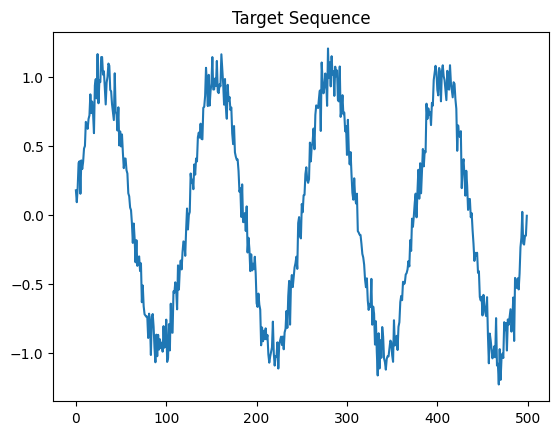

Epoch 0 Loss: [0.29517075]
Epoch 50 Loss: [0.01666396]


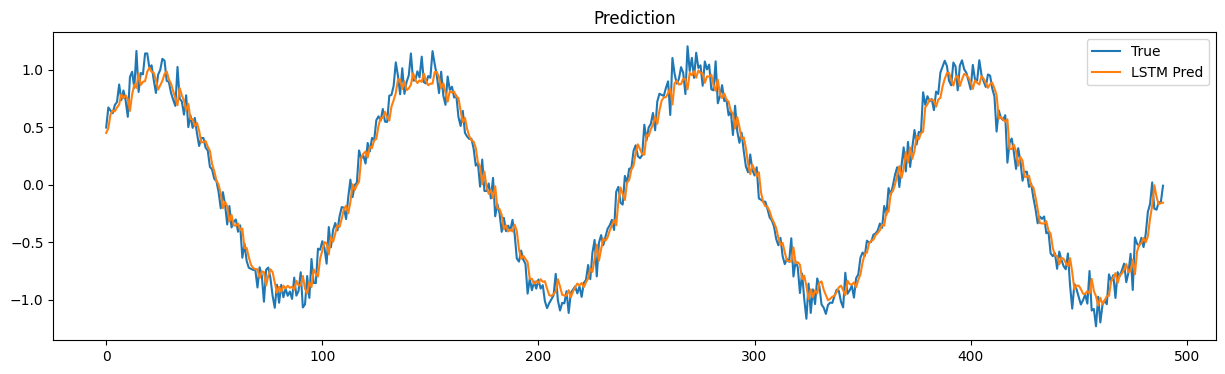

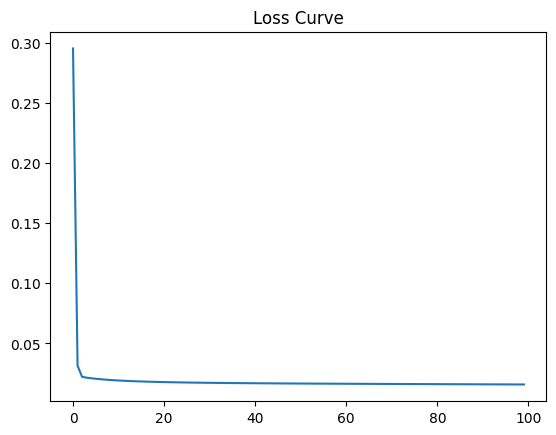

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# 1️⃣ Sine wave
T = 500
x = np.linspace(0, 8 * np.pi, T)
y = np.sin(x) + 0.1 * np.random.randn(T)

plt.plot(y)
plt.title("Target Sequence")
plt.show()

# Normalize
y_mean, y_std = y.mean(), y.std()
y_norm = (y - y_mean) / y_std

# Windowed dataset
seq_len = 10
X = []
Y = []
for i in range(T - seq_len):
    X.append(y_norm[i:i+seq_len])
    Y.append(y_norm[i+seq_len])
    
X = np.array(X)  # (N, seq_len)
Y = np.array(Y).reshape(-1, 1)
N = len(X)

# 2️⃣ Helpers
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def dsigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)
def dtanh(x):
    return 1 - np.tanh(x)**2

# 3️⃣ LSTM params
hidden_size = 16
lr = 0.01
epochs = 100

Wx_f = np.random.randn(hidden_size, 1) * 0.1
Wh_f = np.random.randn(hidden_size, hidden_size) * 0.1
bf = np.zeros((hidden_size, 1))

Wx_i = np.random.randn(hidden_size, 1) * 0.1
Wh_i = np.random.randn(hidden_size, hidden_size) * 0.1
bi = np.zeros((hidden_size, 1))

Wx_c = np.random.randn(hidden_size, 1) * 0.1
Wh_c = np.random.randn(hidden_size, hidden_size) * 0.1
bc = np.zeros((hidden_size, 1))

Wx_o = np.random.randn(hidden_size, 1) * 0.1
Wh_o = np.random.randn(hidden_size, hidden_size) * 0.1
bo = np.zeros((hidden_size, 1))

Wy = np.random.randn(1, hidden_size) * 0.1
by = np.zeros((1, 1))

losses = []

# 4️⃣ TRAIN
for epoch in range(epochs):
    total_loss = 0

    for n in range(N):
        # Forward
        h_prev = np.zeros((hidden_size, 1))
        C_prev = np.zeros((hidden_size, 1))
        gates = []

        for t in range(seq_len):
            x_t = np.array([[X[n, t]]])
            f_t = sigmoid(Wx_f @ x_t + Wh_f @ h_prev + bf)
            i_t = sigmoid(Wx_i @ x_t + Wh_i @ h_prev + bi)
            C_tilde = np.tanh(Wx_c @ x_t + Wh_c @ h_prev + bc)
            C = f_t * C_prev + i_t * C_tilde
            o_t = sigmoid(Wx_o @ x_t + Wh_o @ h_prev + bo)
            h = o_t * np.tanh(C)
            gates.append((x_t, f_t, i_t, C_tilde, o_t, h_prev, C_prev, C, h))
            h_prev = h
            C_prev = C

        y_hat = Wy @ h + by
        loss = (y_hat - Y[n])**2 / 2
        total_loss += loss

        # Backprop output
        dy = y_hat - Y[n]
        dWy = dy @ h.T
        dby = dy

        # Backprop through time
        dh_next = Wy.T @ dy
        dC_next = np.zeros_like(C)

        dWx_f = np.zeros_like(Wx_f)
        dWh_f = np.zeros_like(Wh_f)
        dbf = np.zeros_like(bf)

        dWx_i = np.zeros_like(Wx_i)
        dWh_i = np.zeros_like(Wh_i)
        dbi = np.zeros_like(bi)

        dWx_c = np.zeros_like(Wx_c)
        dWh_c = np.zeros_like(Wh_c)
        dbc = np.zeros_like(bc)

        dWx_o = np.zeros_like(Wx_o)
        dWh_o = np.zeros_like(Wh_o)
        dbo = np.zeros_like(bo)

        for t in reversed(range(seq_len)):
            x_t, f_t, i_t, C_tilde, o_t, h_prev, C_prev, C, h = gates[t]

            dh = dh_next
            do = dh * np.tanh(C)
            do_raw = do * o_t * (1 - o_t)

            dC = dh * o_t * dtanh(C) + dC_next
            dC_next = dC * f_t

            di = dC * C_tilde
            di_raw = di * i_t * (1 - i_t)

            dC_tilde = dC * i_t
            dC_tilde_raw = dC_tilde * dtanh(C_tilde)

            df = dC * C_prev
            df_raw = df * f_t * (1 - f_t)

            dWx_f += df_raw @ x_t.T
            dWh_f += df_raw @ h_prev.T
            dbf += df_raw

            dWx_i += di_raw @ x_t.T
            dWh_i += di_raw @ h_prev.T
            dbi += di_raw

            dWx_c += dC_tilde_raw @ x_t.T
            dWh_c += dC_tilde_raw @ h_prev.T
            dbc += dC_tilde_raw

            dWx_o += do_raw @ x_t.T
            dWh_o += do_raw @ h_prev.T
            dbo += do_raw

            dh_next = (
                Wh_f.T @ df_raw +
                Wh_i.T @ di_raw +
                Wh_c.T @ dC_tilde_raw +
                Wh_o.T @ do_raw
            )

        # Apply updates
        for p, dp in zip(
            [Wx_f, Wh_f, bf, Wx_i, Wh_i, bi, Wx_c, Wh_c, bc, Wx_o, Wh_o, bo, Wy, by],
            [dWx_f, dWh_f, dbf, dWx_i, dWh_i, dbi, dWx_c, dWh_c, dbc, dWx_o, dWh_o, dbo, dWy, dby]
        ):
            p -= lr * dp

    losses.append(total_loss[0] / N)

    if epoch % 50 == 0:
        print(f"Epoch {epoch} Loss: {total_loss[0] / N}")

# 5️⃣ Inference
pred = []
for n in range(N):
    h_prev = np.zeros((hidden_size, 1))
    C_prev = np.zeros((hidden_size, 1))

    for t in range(seq_len):
        x_t = np.array([[X[n, t]]])
        f_t = sigmoid(Wx_f @ x_t + Wh_f @ h_prev + bf)
        i_t = sigmoid(Wx_i @ x_t + Wh_i @ h_prev + bi)
        C_tilde = np.tanh(Wx_c @ x_t + Wh_c @ h_prev + bc)
        C = f_t * C_prev + i_t * C_tilde
        o_t = sigmoid(Wx_o @ x_t + Wh_o @ h_prev + bo)
        h = o_t * np.tanh(C)
        h_prev, C_prev = h, C

    y_hat = Wy @ h + by
    pred.append(y_hat[0,0])

pred = np.array(pred)

# 6️⃣ Plot
plt.figure(figsize=(15, 4))
plt.plot(Y.flatten() * y_std + y_mean, label="True")
plt.plot(pred * y_std + y_mean, label="LSTM Pred")
plt.legend()
plt.title("Prediction")
plt.show()

plt.plot(losses)
plt.title("Loss Curve")
plt.show()

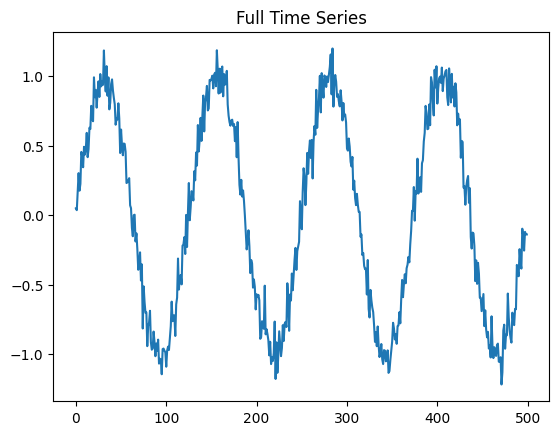

Epoch 0 | LSTM Loss: [0.24142686] | RNN Loss: [0.07906043]
Epoch 50 | LSTM Loss: [0.01621834] | RNN Loss: [0.01751188]
Epoch 100 | LSTM Loss: [0.01518504] | RNN Loss: [0.01742327]
Epoch 150 | LSTM Loss: [0.0146384] | RNN Loss: [0.01739606]


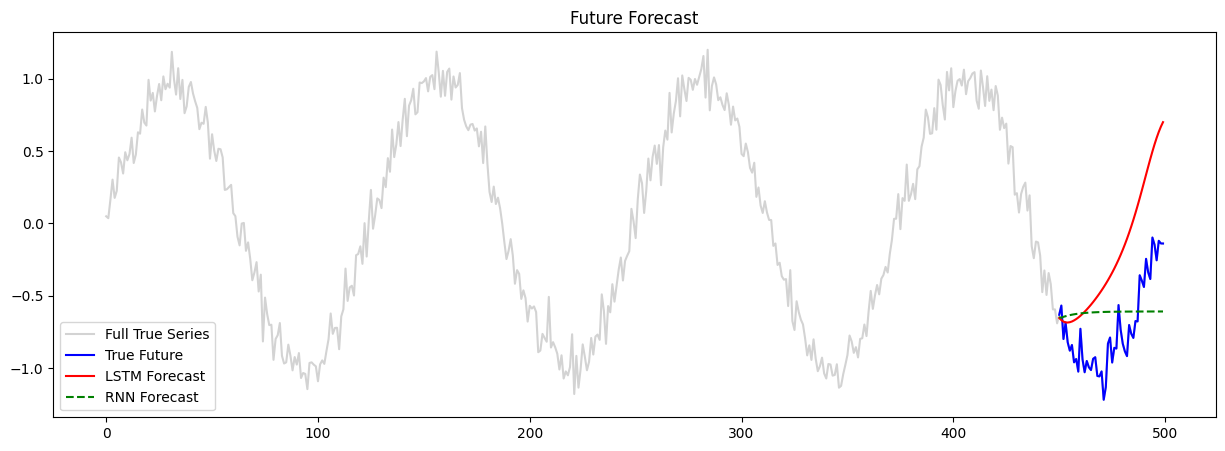

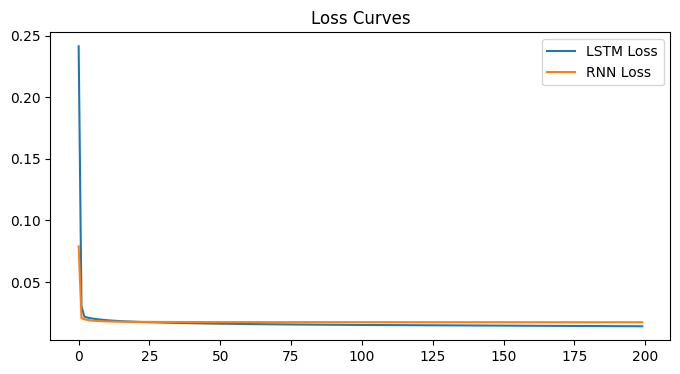

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Data ---
T = 500
x = np.linspace(0, 8 * np.pi, T)
y = np.sin(x) + 0.1 * np.random.randn(T)

plt.plot(y)
plt.title("Full Time Series")
plt.show()

# Normalize
y_mean, y_std = y.mean(), y.std()
y_norm = (y - y_mean) / y_std

# --- Train/Test split ---
seq_len = 20
future_steps = 50

train_data = y_norm[:-future_steps]
test_data = y_norm[-(future_steps + seq_len):]

X = []
Y = []
for i in range(len(train_data) - seq_len):
    X.append(train_data[i:i+seq_len])
    Y.append(train_data[i+seq_len])
X = np.array(X)
Y = np.array(Y).reshape(-1, 1)
N = len(X)

# --- Helpers ---
def sigmoid(x): return 1 / (1 + np.exp(-x))
def dtanh(x): return 1 - np.tanh(x)**2

# --- LSTM params ---
hidden_size = 16
lr = 0.01
epochs = 200

Wx_f = np.random.randn(hidden_size, 1) * 0.1
Wh_f = np.random.randn(hidden_size, hidden_size) * 0.1
bf = np.zeros((hidden_size, 1))

Wx_i = np.random.randn(hidden_size, 1) * 0.1
Wh_i = np.random.randn(hidden_size, hidden_size) * 0.1
bi = np.zeros((hidden_size, 1))

Wx_c = np.random.randn(hidden_size, 1) * 0.1
Wh_c = np.random.randn(hidden_size, hidden_size) * 0.1
bc = np.zeros((hidden_size, 1))

Wx_o = np.random.randn(hidden_size, 1) * 0.1
Wh_o = np.random.randn(hidden_size, hidden_size) * 0.1
bo = np.zeros((hidden_size, 1))

Wy = np.random.randn(1, hidden_size) * 0.1
by = np.zeros((1, 1))

losses_lstm = []

# --- RNN params ---
Wx_rnn = np.random.randn(hidden_size, 1) * 0.1
Wh_rnn = np.random.randn(hidden_size, hidden_size) * 0.1
Wy_rnn = np.random.randn(1, hidden_size) * 0.1
bh_rnn = np.zeros((hidden_size, 1))
by_rnn = np.zeros((1, 1))

losses_rnn = []

# --- Train both ---
for epoch in range(epochs):
    total_loss_lstm = 0
    total_loss_rnn = 0

    # LSTM loop
    for n in range(N):
        h_prev = np.zeros((hidden_size, 1))
        C_prev = np.zeros((hidden_size, 1))
        gates = []

        for t in range(seq_len):
            x_t = np.array([[X[n, t]]])
            f_t = sigmoid(Wx_f @ x_t + Wh_f @ h_prev + bf)
            i_t = sigmoid(Wx_i @ x_t + Wh_i @ h_prev + bi)
            C_tilde = np.tanh(Wx_c @ x_t + Wh_c @ h_prev + bc)
            C = f_t * C_prev + i_t * C_tilde
            o_t = sigmoid(Wx_o @ x_t + Wh_o @ h_prev + bo)
            h = o_t * np.tanh(C)
            gates.append((x_t, f_t, i_t, C_tilde, o_t, h_prev, C_prev, C, h))
            h_prev, C_prev = h, C

        y_hat = Wy @ h + by
        loss = (y_hat - Y[n])**2 / 2
        total_loss_lstm += loss

        dy = y_hat - Y[n]
        dWy = dy @ h.T
        dby = dy

        dh_next = Wy.T @ dy
        dC_next = np.zeros_like(C)

        dWx_f = np.zeros_like(Wx_f)
        dWh_f = np.zeros_like(Wh_f)
        dbf = np.zeros_like(bf)

        dWx_i = np.zeros_like(Wx_i)
        dWh_i = np.zeros_like(Wh_i)
        dbi = np.zeros_like(bi)

        dWx_c = np.zeros_like(Wx_c)
        dWh_c = np.zeros_like(Wh_c)
        dbc = np.zeros_like(bc)

        dWx_o = np.zeros_like(Wx_o)
        dWh_o = np.zeros_like(Wh_o)
        dbo = np.zeros_like(bo)

        for t in reversed(range(seq_len)):
            x_t, f_t, i_t, C_tilde, o_t, h_prev, C_prev, C, h = gates[t]

            dh = dh_next
            do = dh * np.tanh(C)
            do_raw = do * o_t * (1 - o_t)

            dC = dh * o_t * dtanh(C) + dC_next
            dC_next = dC * f_t

            di = dC * C_tilde
            di_raw = di * i_t * (1 - i_t)

            dC_tilde = dC * i_t
            dC_tilde_raw = dC_tilde * dtanh(C_tilde)

            df = dC * C_prev
            df_raw = df * f_t * (1 - f_t)

            dWx_f += df_raw @ x_t.T
            dWh_f += df_raw @ h_prev.T
            dbf += df_raw

            dWx_i += di_raw @ x_t.T
            dWh_i += di_raw @ h_prev.T
            dbi += di_raw

            dWx_c += dC_tilde_raw @ x_t.T
            dWh_c += dC_tilde_raw @ h_prev.T
            dbc += dC_tilde_raw

            dWx_o += do_raw @ x_t.T
            dWh_o += do_raw @ h_prev.T
            dbo += do_raw

            dh_next = (
                Wh_f.T @ df_raw +
                Wh_i.T @ di_raw +
                Wh_c.T @ dC_tilde_raw +
                Wh_o.T @ do_raw
            )

        for p, dp in zip(
            [Wx_f, Wh_f, bf, Wx_i, Wh_i, bi, Wx_c, Wh_c, bc, Wx_o, Wh_o, bo, Wy, by],
            [dWx_f, dWh_f, dbf, dWx_i, dWh_i, dbi, dWx_c, dWh_c, dbc, dWx_o, dWh_o, dbo, dWy, dby]
        ):
            p -= lr * dp

    losses_lstm.append(total_loss_lstm[0] / N)

    # RNN loop
    for n in range(N):
        h_prev = np.zeros((hidden_size, 1))

        for t in range(seq_len):
            x_t = np.array([[X[n, t]]])
            a_t = Wx_rnn @ x_t + Wh_rnn @ h_prev + bh_rnn
            h = np.tanh(a_t)
            h_prev = h

        y_hat = Wy_rnn @ h + by_rnn
        loss = (y_hat - Y[n])**2 / 2
        total_loss_rnn += loss

        dy = y_hat - Y[n]
        dWy_rnn = dy @ h.T
        dby_rnn = dy

        dh = Wy_rnn.T @ dy

        dWx_rnn = np.zeros_like(Wx_rnn)
        dWh_rnn = np.zeros_like(Wh_rnn)
        dbh_rnn = np.zeros_like(bh_rnn)

        for t in reversed(range(seq_len)):
            x_t = np.array([[X[n, t]]])
            da = dh * dtanh(a_t)
            dWx_rnn += da @ x_t.T
            dWh_rnn += da @ h_prev.T
            dbh_rnn += da
            dh = Wh_rnn.T @ da

        Wy_rnn -= lr * dWy_rnn
        by_rnn -= lr * dby_rnn
        Wx_rnn -= lr * dWx_rnn
        Wh_rnn -= lr * dWh_rnn
        bh_rnn -= lr * dbh_rnn

    losses_rnn.append(total_loss_rnn[0] / N)

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | LSTM Loss: {losses_lstm[-1]:} | RNN Loss: {losses_rnn[-1]:}")

# --- Forecast ---
# LSTM
window = y_norm[-(future_steps + seq_len):-future_steps].tolist()
pred_future_lstm = []

for _ in range(future_steps):
    h_prev = np.zeros((hidden_size, 1))
    C_prev = np.zeros((hidden_size, 1))
    for t in range(seq_len):
        x_t = np.array([[window[t]]])
        f_t = sigmoid(Wx_f @ x_t + Wh_f @ h_prev + bf)
        i_t = sigmoid(Wx_i @ x_t + Wh_i @ h_prev + bi)
        C_tilde = np.tanh(Wx_c @ x_t + Wh_c @ h_prev + bc)
        C = f_t * C_prev + i_t * C_tilde
        o_t = sigmoid(Wx_o @ x_t + Wh_o @ h_prev + bo)
        h = o_t * np.tanh(C)
        h_prev, C_prev = h, C
    y_hat = Wy @ h + by
    pred_future_lstm.append(y_hat[0, 0])
    window.append(y_hat[0, 0])
    window.pop(0)

# RNN
window = y_norm[-(future_steps + seq_len):-future_steps].tolist()
pred_future_rnn = []

for _ in range(future_steps):
    h_prev = np.zeros((hidden_size, 1))
    for t in range(seq_len):
        x_t = np.array([[window[t]]])
        a_t = Wx_rnn @ x_t + Wh_rnn @ h_prev + bh_rnn
        h = np.tanh(a_t)
        h_prev = h
    y_hat = Wy_rnn @ h + by_rnn
    pred_future_rnn.append(y_hat[0, 0])
    window.append(y_hat[0, 0])
    window.pop(0)

# --- Plot ---
true_future = test_data[seq_len:] * y_std + y_mean
lstm_forecast = np.array(pred_future_lstm) * y_std + y_mean
rnn_forecast = np.array(pred_future_rnn) * y_std + y_mean

plt.figure(figsize=(15, 5))
plt.plot(y, color="lightgray", label="Full True Series")
plt.plot(range(len(y) - future_steps, len(y)),
         true_future, label="True Future", color="blue")
plt.plot(range(len(y) - future_steps, len(y)),
         lstm_forecast, label="LSTM Forecast", color="red")
plt.plot(range(len(y) - future_steps, len(y)),
         rnn_forecast, label="RNN Forecast", color="green", linestyle="--")
plt.title("Future Forecast")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(losses_lstm, label="LSTM Loss")
plt.plot(losses_rnn, label="RNN Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()